In [1]:
!pip install -q google-adk google-genai pymupdf pillow python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 35.6 MB/s eta 0:00:00


In [3]:
import os
from google.colab import userdata
from google import genai

os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

client = genai.Client()

In [4]:
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="Say: StudyGenie is ready!"
)

print(response.text)

StudyGenie is ready!


In [ ]:
STUDYGENIE_PROMPT = """
You are StudyGenie, an Adaptive AI Study Coach.

Your responsibilities:
- Explain concepts clearly.
- Summarize study materials.
- Answer questions based on the uploaded content.
- If the uploaded material doesn't contain the answer, clearly say so.
- Never make up facts.
- Use simple language unless the user asks for advanced explanations.
"""

In [ ]:
def ask_studygenie(question):
    prompt = f"""
{STUDYGENIE_PROMPT}

User Question:
{question}
"""

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    return response.text

In [ ]:
question = "Explain what overfitting is in simple words."

answer = ask_studygenie(question)

print(answer)

Overfitting is when a computer model learns too much specific detail from the data it was trained on, including the "noise" or random errors in that data.

Think of it this way:

Imagine you're studying for a math test.

*   **Good learning:** You understand the formulas, the methods, and how to solve different types of problems. When a new problem comes up on the test, you can apply your understanding to solve it, even if you haven't seen that exact problem before.
*   **Overfitting:** Instead of understanding the math concepts, you *memorize the answers to every single practice problem* you've ever seen. You know that "Problem A has answer X," and "Problem B has answer Y."

**The problem with overfitting:**

When you get to the actual test, if a question is even slightly different from the practice problems you memorized, you won't know how to answer it because you didn't learn the underlying rules. You're great at the *exact* practice problems, but terrible at new, similar problems.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving The New SDLC With Vibe Coding_Day_1.pdf to The New SDLC With Vibe Coding_Day_1.pdf


In [ ]:
import fitz

pdf_file = list(uploaded.keys())[0]

doc = fitz.open(pdf_file)

pdf_text = ""

for page in doc:
    pdf_text += page.get_text()

doc.close()

print(pdf_text[:1000])

The New SDLC  
With Vibe Coding 
 
 
Authors: Addy Osmani, Shubham Saboo,  
and Sokratis Kartakis
From ad-hoc prompting to  
Agentic Engineering
The new SDLC with vibe coding
May 2026
2
Acknowledgements
Content contributors
Elia Secchi
Julia Wiesinger
Anant Nawalgaria
Curators and editors
Anant Nawalgaria
Designer
Michael Lanning 
Introduction
6
Why this paper, why now
9
Who this paper is for
9
The shift from syntax to intent
10
AI Agents: A Quick Refresher
10
What is vibe coding?
11
The spectrum: vibe coding to agentic engineering
12
Context engineering: the real skill
15
The new software development life cycle
19
The traditional SDLC under pressure
19
How AI transforms each phase
21
Requirements and planning	
21
Design and architecture	
21
Implementation	
22
Testing and quality assurance	
22
Table of contents
Code review and deployment	
23
Maintenance and evolution	
24
The factory model: building the system that builds software
24
Harness Engineering: What surrounds the m

In [ ]:
def ask_pdf(pdf_text, question):
    prompt = f"""
{STUDYGENIE_PROMPT}

Study Material:
{pdf_text}

User Question:
{question}
"""

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    return response.text

In [ ]:
question = "Give me a summary of this PDF in 5 bullet points."

answer = ask_pdf(pdf_text, question)

print(answer)

Here's a summary of the provided study material in 5 bullet points:

*   **Shift from Syntax to Intent:** Software engineering is undergoing a major transformation from writing code (syntax) to expressing what needs to be built (intent), with AI systems handling the implementation.
*   **Vibe Coding vs. Agentic Engineering:** AI-assisted development exists on a spectrum from casual "vibe coding" (quick prompts, minimal verification) to disciplined "agentic engineering" (structured systems, rigorous testing, human oversight), with the latter being crucial for reliable production software.
*   **Importance of Harness & Context Engineering:** The effectiveness of AI agents depends less on clever prompts and more on the quality of the "harness" (the surrounding scaffolding like tools, memory, guardrails) and "context engineering" (providing rich, structured information to the AI).
*   **Transformation of the SDLC:** AI dramatically reshapes every phase of the Software Development Life Cycl

Saving Screenshot 2026-07-03 at 11.50.14 PM.png to Screenshot 2026-07-03 at 11.50.14 PM.png


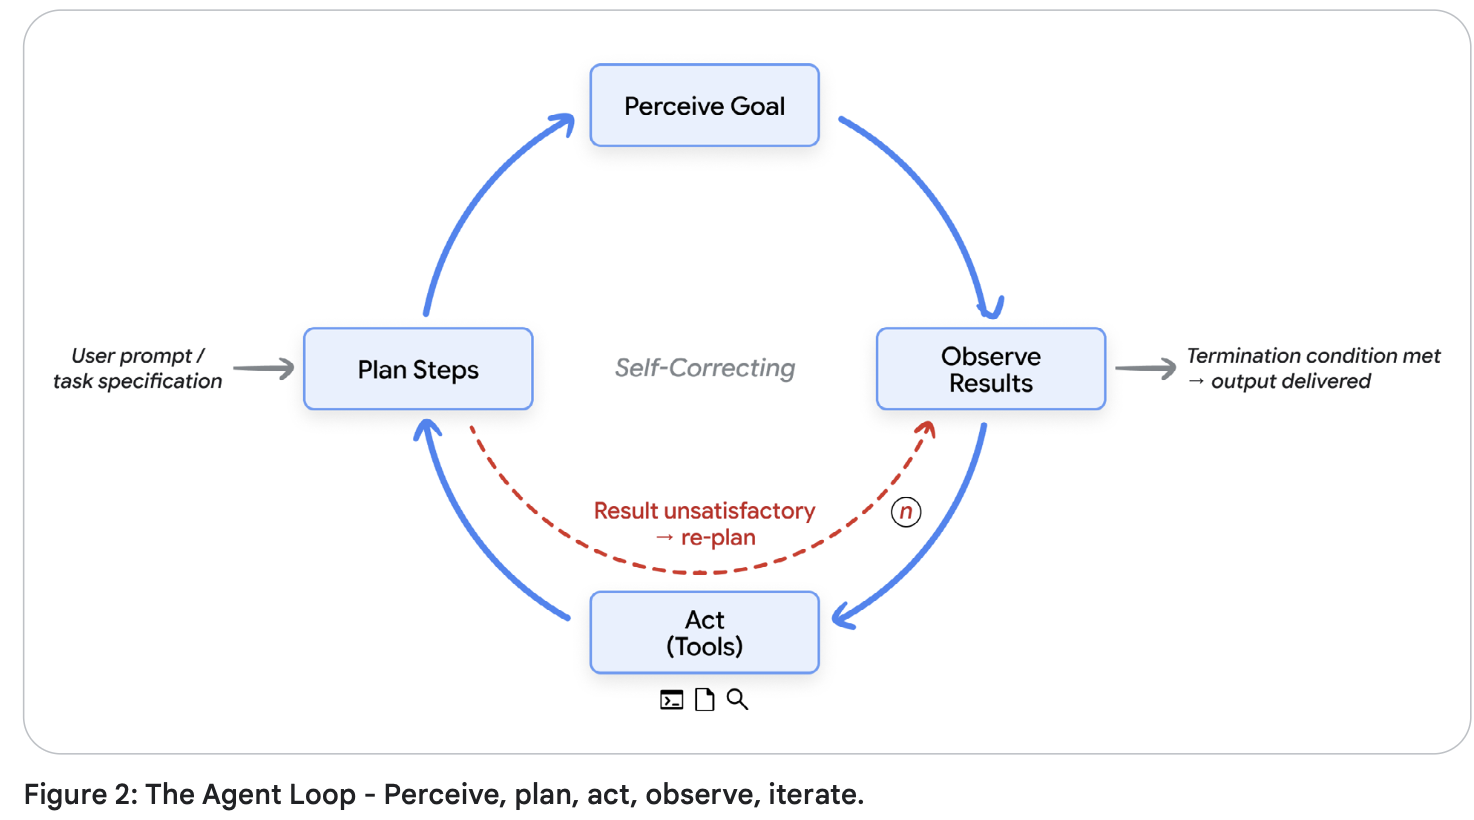

In [ ]:
from PIL import Image
from google.colab import files

uploaded_image = files.upload()

image_path = list(uploaded_image.keys())[0]

image = Image.open(image_path)

image

In [ ]:
def ask_image(image, question):

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=[
            question,
            image
        ]
    )

    return response.text

In [ ]:
question = "Explain this page in simple words."

answer = ask_image(image, question)

print(answer)

Imagine you're asking a smart assistant (an "Agent") to do something for you, like "write a summary of yesterday's news." This diagram shows how that assistant thinks and works:

1.  **You Tell It What To Do (User prompt / task specification):** You give the AI a job or a question.

2.  **It Understands the Big Picture (Perceive Goal):** The AI first makes sure it knows what the main aim is – what's the ultimate goal of your request?

3.  **It Makes a Plan (Plan Steps):** Based on the goal, the AI thinks about how to achieve it. It breaks your request down into smaller, actionable steps. For example, "First, I need to find yesterday's news. Then, I need to read it. Finally, I'll write a summary."

4.  **It Takes Action (Act - Tools):** The AI then actually *does* those steps. It might use various "tools" like searching the internet, opening a document, performing calculations, or writing text.

5.  **It Checks the Results (Observe Results):** After taking action, the AI looks at what h

In [ ]:
print("🎉 Day 1 Completed Successfully!")

print("""
Completed Features:
✅ StudyGenie Agent
✅ Gemini Integration
✅ Text Questions
✅ PDF Upload & Q&A
✅ Image Upload & Q&A
""")

🎉 Day 1 Completed Successfully!

Completed Features:
✅ StudyGenie Agent
✅ Gemini Integration
✅ Text Questions
✅ PDF Upload & Q&A
✅ Image Upload & Q&A



In [ ]:
memory = []

In [ ]:
def add_to_memory(user_input, assistant_output):
    memory.append({
        "user": user_input,
        "assistant": assistant_output
    })

In [ ]:
def get_memory_context():
    context = ""

    for item in memory[-5:]:
        context += f"User: {item['user']}\n"
        context += f"StudyGenie: {item['assistant']}\n\n"

    return context

In [ ]:
def ask_studygenie_with_memory(question):

    prompt = f"""
{STUDYGENIE_PROMPT}

Previous Conversation:
{get_memory_context()}

Current User Question:
{question}
"""

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    answer = response.text

    add_to_memory(question, answer)

    return answer

In [ ]:
answer1 = ask_studygenie_with_memory(
    "Explain machine learning in simple words."
)

print(answer1)

Machine learning is a way of teaching computers to learn from data, much like how humans learn from experience.

Instead of being explicitly programmed for every single task, you give a machine a lot of examples (data). The machine then looks for patterns in that data and figures out how to make predictions or decisions on its own.

**Think of it like this:**

*   **Teaching a child to identify a cat:** You don't give the child a strict set of rules (e.g., "it has pointy ears, four legs, whiskers, and a tail"). Instead, you show them many pictures of cats and say, "This is a cat." You also show them pictures of dogs and say, "This is *not* a cat." After seeing enough examples, the child learns to identify a cat even if they see one they've never seen before.
*   **Machine learning works similarly:** You feed a computer thousands of images labeled "cat" and thousands labeled "not cat." The computer then "learns" what features generally make something a cat. When it sees a new image, it 

In [ ]:
answer2 = ask_studygenie_with_memory(
    "Can you explain it again using an everyday example?"
)

print(answer2)

Certainly! Let's try another everyday example.

Imagine your favorite music streaming app, like Spotify or Apple Music.

**How your music app uses Machine Learning:**

*   **Learning about you:** The app watches what songs you listen to, which ones you skip, which ones you add to playlists, and which artists you follow. It also looks at what time of day you listen, or what genre you prefer for different moods.
*   **Learning from others:** It also considers what millions of other users listen to, especially those who have similar tastes to yours.
*   **Making a prediction (or suggestion):** Based on all this information, the app's machine learning system starts to understand your unique musical taste. It finds patterns like, "People who listen to Artist X and Artist Y also tend to like Artist Z."
*   **Giving you personalized recommendations:** So, when the app creates a "Discover Weekly" playlist for you or suggests new artists, it's not a person sitting there picking songs. Instead, 

In [ ]:
def generate_quiz(study_material):

    prompt = f"""
You are StudyGenie.

Create a quiz from the following study material.

Requirements:
- 5 multiple-choice questions
- 4 options for each question
- Mention the correct answer after each question.

Study Material:
{study_material}
"""

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    return response.text

In [ ]:
quiz = generate_quiz(pdf_text)

print(quiz)

Here is your quiz from the provided study material:

---

### StudyGenie Quiz: The New SDLC with Vibe Coding

**Question 1:** According to the study material, what is the most profound shift occurring in software engineering?
A) The introduction of new programming languages.
B) The transition from writing code to expressing intent.
C) The adoption of cloud services.
D) The development of new frameworks.
**Correct Answer: B) The transition from writing code to expressing intent.**

**Question 2:** How is an AI agent primarily defined in the study material?
A) A chatbot that produces a response and waits for the next prompt.
B) A software system that perceives a goal, plans steps, takes actions, observes results, and iterates to meet that goal.
C) A tool that provides inline code suggestions.
D) A system that only generates multi-file changes without human intervention.
**Correct Answer: B) A software system that perceives a goal, plans steps, takes actions, observes results, and iterate

In [ ]:
def generate_flashcards(study_material):

    prompt = f"""
You are StudyGenie.

Create flashcards from the following study material.

Requirements:
- Generate 10 flashcards.
- Format:
  Front: Question/Term
  Back: Answer/Explanation

Study Material:
{study_material}
"""

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    return response.text

In [ ]:
flashcards = generate_flashcards(pdf_text)

print(flashcards)

Here are 10 flashcards generated from the study material:

---

**Flashcard 1**
**Front:** What is the most profound shift occurring in software engineering today, according to the study material?
**Back:** It's the transition from writing code to expressing intent, and trusting intelligent systems to translate that intent into working software.

---

**Flashcard 2**
**Front:** Define an "AI Agent" as described in the study material.
**Back:** An AI agent is a software system that perceives a goal, plans steps to reach it, takes actions through tools, observes the results, and iterates until the goal is met or it hits a stopping condition.

---

**Flashcard 3**
**Front:** What are the five core parts that every AI agent is built from?
**Back:** The five parts are:
1.  **Model:** The reasoning engine.
2.  **Tools:** Connect the model to the world (APIs, code, databases).
3.  **Memory:** The state, allowing recall of past interactions and context.
4.  **Orchestration:** The code that run

In [ ]:
def generate_study_plan(study_material):

    prompt = f"""
You are StudyGenie.

Create a personalized study plan based on the following study material.

Requirements:
- Divide the study into 5 sessions.
- Mention the topic(s) to study in each session.
- Include an estimated study time.
- Suggest a short revision task after each session.
- End with a final revision plan.

Study Material:
{study_material}
"""

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    return response.text

In [ ]:
study_plan = generate_study_plan(pdf_text)

print(study_plan)

Hello there! I'm StudyGenie, ready to help you navigate "The New SDLC with Vibe Coding." This paper introduces some exciting and critical shifts in software development. Let's break it down into a manageable and effective 5-session study plan.

---

### Your Personalized Study Plan: The New SDLC with Vibe Coding

This plan is designed to help you progressively understand the core concepts, practical implications, and strategic considerations presented in the paper.

---

#### **Session 1: Foundations – The Shift to Intent & AI Agent Basics**

*   **Topics to Study:**
    *   Introduction: Why this paper, why now; Who this paper is for; The shift from syntax to intent.
    *   AI Agents: A Quick Refresher (Model, Tools, Memory, Orchestration, Deployment).
    *   What is vibe coding?
    *   The spectrum: vibe coding to agentic engineering.
*   **Estimated Study Time:** 1 hour
*   **Short Revision Task:** In your own words, define "vibe coding" and "agentic engineering," highlighting th

In [ ]:
answer1 = ask_studygenie_with_memory(
    "I am preparing for my Machine Learning exam."
)

print(answer1)

That's great! I can definitely help you with your Machine Learning exam preparation.

Feel free to ask me anything you need. For example, you can:
*   Ask me to explain specific Machine Learning concepts.
*   Ask me to summarize any study materials you might upload (though I can't process uploads in this text-only format).
*   Test your understanding with questions.

What topic would you like to start with, or do you have a specific question in mind?


In [ ]:
answer2 = ask_studygenie_with_memory(
    "Create a study plan for me based on that."
)

print(answer2)

Okay, that's a great goal! While I don't know your specific exam date or syllabus, I can create a comprehensive, general study plan for a Machine Learning exam. You can adapt this plan based on your course material and how much time you have.

Let's break down the core areas of Machine Learning into a structured plan:

---

### **General Machine Learning Exam Study Plan**

**Goal:** Understand core ML concepts, algorithms, evaluation, and practical considerations.

**How to Use This Plan:**
*   **Adapt Timeframes:** Adjust "Week 1," "Week 2," etc., to fit your personal schedule. If you have less time, combine topics; if more, delve deeper.
*   **Prioritize:** Focus more on topics that your course emphasizes.
*   **Active Learning:** Don't just read. Try to explain concepts in your own words, draw diagrams, and work through examples.
*   **Practice:** Machine Learning involves a lot of math and logic. Practice problems (if available from your course) are crucial.

---

**Phase 1: Founda